# 06 - Evaluation

A closer look at where the model in `05_modeling.ipynb` does well and where
it doesn't, plus an honest list of limitations.


In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

from src.features import prepare_model_inputs

sns.set_style("whitegrid")

train_df = pd.read_csv("../data/processed/train_features.csv")
X, ids, groups = prepare_model_inputs(train_df)
y = train_df["Target_Turnout"]

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
ids_test = ids.iloc[test_idx]

model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse*100:.1f} pp")
print(f"MAE: {mae*100:.1f} pp")

R²: 0.443
RMSE: 6.4 pp
MAE: 4.7 pp


## Predicted vs actual

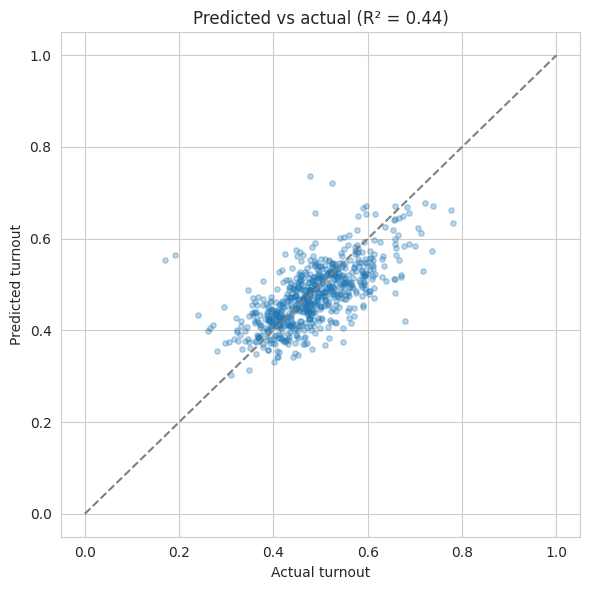

In [2]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=15)
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("Actual turnout")
ax.set_ylabel("Predicted turnout")
ax.set_title(f"Predicted vs actual (R² = {r2:.2f})")
plt.tight_layout()
plt.show()

## Where is the model most wrong?

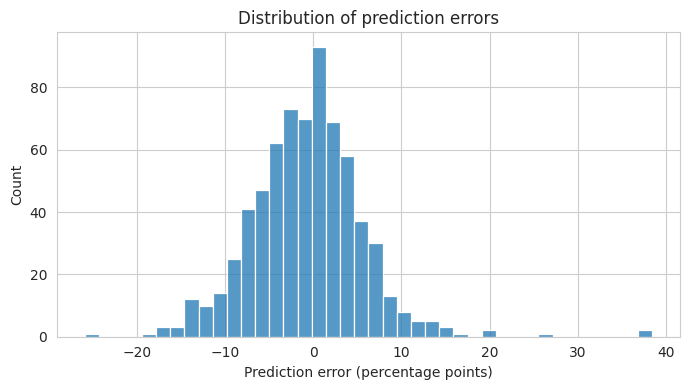

Largest overpredictions:
           Province MunicipalityCode    Actual  Predicted     Error
1775  KwaZulu-Natal           KZN226  0.170553   0.554046  0.383492
1778  KwaZulu-Natal           KZN226  0.191673   0.563667  0.371995
3941  Northern Cape            NC453  0.477090   0.737226  0.260137
3781  Northern Cape            NC073  0.524248   0.722015  0.197766
3469     North West            NW375  0.240983   0.433312  0.192329

Largest underpredictions:
           Province MunicipalityCode    Actual  Predicted     Error
3465     North West            NW375  0.679016   0.420647 -0.258369
2094  KwaZulu-Natal           KZN272  0.717181   0.530398 -0.186783
3938  Northern Cape            NC453  0.657143   0.481731 -0.175412
833      Free State            FS193  0.546443   0.374281 -0.172162
1895  KwaZulu-Natal           KZN244  0.737178   0.572919 -0.164259


In [3]:
errors = ids_test.copy()
errors["Actual"] = y_test.values
errors["Predicted"] = y_pred
errors["Error"] = errors["Predicted"] - errors["Actual"]
errors["AbsError"] = errors["Error"].abs()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(errors["Error"] * 100, bins=40, ax=ax)
ax.set_xlabel("Prediction error (percentage points)")
ax.set_title("Distribution of prediction errors")
plt.tight_layout()
plt.show()

print("Largest overpredictions:")
print(errors.sort_values("Error", ascending=False).head(5)[["Province", "MunicipalityCode", "Actual", "Predicted", "Error"]])
print()
print("Largest underpredictions:")
print(errors.sort_values("Error").head(5)[["Province", "MunicipalityCode", "Actual", "Predicted", "Error"]])

Errors are roughly centered around 0, which is what we'd want - the model
isn't systematically biased toward over- or under-predicting. The biggest
misses tend to be wards with unusually large swings between elections,
which the model has no way to see coming from static features alone.

## Does error vary by province or metro status?

In [4]:
errors_by_province = errors.groupby("Province")["AbsError"].mean().sort_values(ascending=False) * 100
errors_by_province

Province
Northern Cape    7.686430
Free State       5.777397
Western Cape     5.535869
North West       5.331004
Gauteng          4.963634
KwaZulu-Natal    4.726897
Mpumalanga       4.331221
Limpopo          3.997455
Eastern Cape     3.574711
Name: AbsError, dtype: float64

## Limitations

Worth stating plainly, not glossing over:

- **Unobserved factors**: turnout depends on things this data can't see -
  candidate scandals, local service-delivery issues, protests, weather on
  election day. No amount of feature engineering fixes this.
- **Only two prior elections** (2016, 2021) for the main model. The 3-year
  panel adds 2011 for trend features, but that's still a short history
  compared to what a proper time-series model would want.
- **Demarcation changes**: ward boundaries shift between elections, so
  some wards had to be dropped from the panel where they couldn't be
  reliably matched across years (see `02_cleaning_and_merge.ipynb` and
  `02b_add_2011.ipynb` for how this was handled).
- **SpoiltRatio isn't available for 2011**, since the raw station-level
  files for that year weren't pulled - only the pre-aggregated
  `ward_panel_3yr.csv`. This means the 3-year feature set is missing this
  feature.
- **Registration growth using a live 2026 snapshot** was considered but
  not included, since that would need scraping the IEC's current voter
  registration dashboard, which wasn't done in the time available.
- Model performance (R² ≈ 0.44, typical error ≈ 6 percentage points) is
  decent but modest - most of the predictive power comes from a ward's
  last-election turnout, with the other features adding real but limited
  extra signal.